In [179]:
import pandas as pd
import numpy as np
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lourenswalters/uci-heart-disease-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'uci-heart-disease-data-set' dataset.
Path to dataset files: /kaggle/input/uci-heart-disease-data-set


In [180]:
print("Files in dataset folder:")

for file in os.listdir(path):
    print(file)

Files in dataset folder:
processed.cleveland.data


In [181]:
import pandas as pd
import numpy as np
import os

# Path to the dataset file
file_path = os.path.join(path, "processed.cleveland.data")

# Column names from the UCI Heart Disease dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

# Load dataset
df = pd.read_csv(
    file_path,
    names=columns,
    na_values="?"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [182]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [183]:
print("Shape of dataset:", df.shape)

Shape of dataset: (303, 14)


In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [185]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [186]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [187]:
print("Target value counts:")
print(df["target"].value_counts().sort_index())

Target value counts:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [188]:
print("\nTarget percentages:")
print(df["target"].value_counts(normalize=True).sort_index() * 100)


Target percentages:
target
0    54.125413
1    18.151815
2    11.881188
3    11.551155
4     4.290429
Name: proportion, dtype: float64


In [189]:
print("Data Types:")
print(df.dtypes)

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


In [190]:
print("Unique values in each column:\n")

for column in df.columns:
    print(column, ":", sorted(df[column].dropna().unique()))

Unique values in each column:

age : [np.float64(29.0), np.float64(34.0), np.float64(35.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(52.0), np.float64(53.0), np.float64(54.0), np.float64(55.0), np.float64(56.0), np.float64(57.0), np.float64(58.0), np.float64(59.0), np.float64(60.0), np.float64(61.0), np.float64(62.0), np.float64(63.0), np.float64(64.0), np.float64(65.0), np.float64(66.0), np.float64(67.0), np.float64(68.0), np.float64(69.0), np.float64(70.0), np.float64(71.0), np.float64(74.0), np.float64(76.0), np.float64(77.0)]
sex : [np.float64(0.0), np.float64(1.0)]
cp : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
trestbps : [np.float64(94.0), np.float64(100.0), np.float64(101.0), np.float64(102.0), np.float64(104.0), np.

In [191]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [192]:
print("\nTotal missing values:", df.isnull().sum().sum())


Total missing values: 6


In [193]:
print("Mode of ca:", df["ca"].mode()[0])
print("Mode of thal:", df["thal"].mode()[0])

Mode of ca: 0.0
Mode of thal: 3.0


In [194]:
df["ca"] = df["ca"].fillna(df["ca"].mode()[0])
df["thal"] = df["thal"].fillna(df["thal"].mode()[0])

In [195]:
print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [196]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


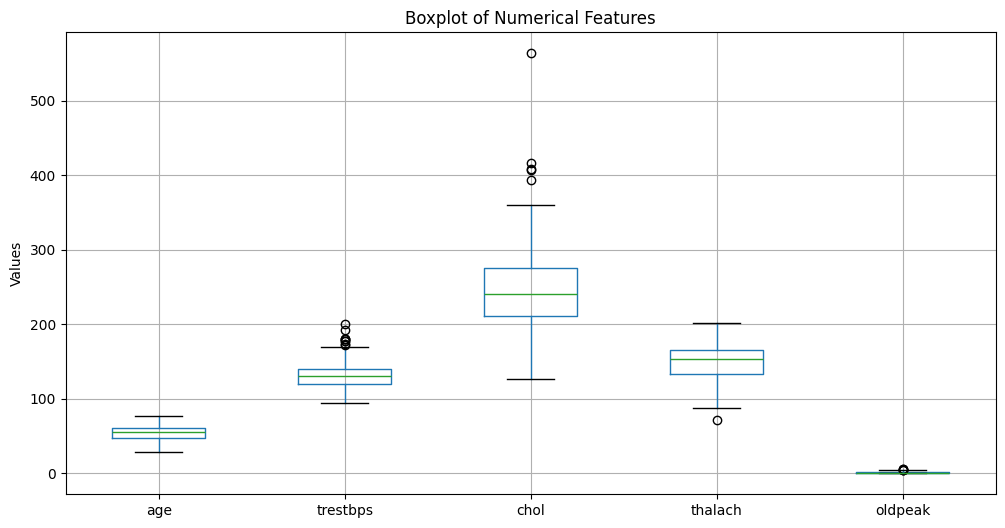

In [197]:
import matplotlib.pyplot as plt

numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

df[numerical_columns].boxplot(figsize=(12, 6))

plt.title("Boxplot of Numerical Features")
plt.ylabel("Values")
plt.show()

In [198]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(f"{column}: {len(outliers)} potential outliers")

age: 0 potential outliers
trestbps: 9 potential outliers
chol: 5 potential outliers
thalach: 1 potential outliers
oldpeak: 5 potential outliers


In [199]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [200]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [201]:
df["target"] = (df["target"] > 0).astype(int)

print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [202]:
X = df.drop("target", axis=1)
y = df["target"]

In [203]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [204]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [205]:
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

Training set: (212, 13)
Validation set: (45, 13)
Testing set: (46, 13)


In [206]:
print("\nTarget distribution:")
print("Training:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTesting:")
print(y_test.value_counts())


Target distribution:
Training:
target
0    115
1     97
Name: count, dtype: int64

Validation:
target
0    24
1    21
Name: count, dtype: int64

Testing:
target
0    25
1    21
Name: count, dtype: int64


In [207]:
# Find the most common value using ONLY the training data

ca_mode = X_train["ca"].mode()[0]
thal_mode = X_train["thal"].mode()[0]

print("Training ca mode:", ca_mode)
print("Training thal mode:", thal_mode)

Training ca mode: 0.0
Training thal mode: 3.0


In [208]:
# Fill missing values in the training set
X_train["ca"] = X_train["ca"].fillna(ca_mode)
X_train["thal"] = X_train["thal"].fillna(thal_mode)

# Use the SAME values for validation
X_val["ca"] = X_val["ca"].fillna(ca_mode)
X_val["thal"] = X_val["thal"].fillna(thal_mode)

# Use the SAME values for testing
X_test["ca"] = X_test["ca"].fillna(ca_mode)
X_test["thal"] = X_test["thal"].fillna(thal_mode)

In [209]:
print("Training missing values:", X_train.isnull().sum().sum())
print("Validation missing values:", X_val.isnull().sum().sum())
print("Testing missing values:", X_test.isnull().sum().sum())

Training missing values: 0
Validation missing values: 0
Testing missing values: 0


In [210]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Numerical features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [211]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

print("One-Hot Encoder created successfully!")

One-Hot Encoder created successfully!


In [212]:
# Fit the encoder ONLY on the training data
encoder.fit(X_train[categorical_features])

# Transform categorical features in all three datasets
X_train_encoded = encoder.transform(X_train[categorical_features])
X_val_encoded = encoder.transform(X_val[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

print("Encoding completed successfully!")

Encoding completed successfully!


In [213]:
print("Original categorical features:", len(categorical_features))
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_val_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Original categorical features: 8
Encoded training shape: (212, 23)
Encoded validation shape: (45, 23)
Encoded testing shape: (46, 23)


In [214]:
print("\nEncoded feature names:")
print(encoder.get_feature_names_out(categorical_features))


Encoded feature names:
['sex_0.0' 'sex_1.0' 'cp_1.0' 'cp_2.0' 'cp_3.0' 'cp_4.0' 'fbs_0.0'
 'fbs_1.0' 'restecg_0.0' 'restecg_1.0' 'restecg_2.0' 'exang_0.0'
 'exang_1.0' 'slope_1.0' 'slope_2.0' 'slope_3.0' 'ca_0.0' 'ca_1.0'
 'ca_2.0' 'ca_3.0' 'thal_3.0' 'thal_6.0' 'thal_7.0']


In [215]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training numerical data
scaler.fit(X_train[numerical_features])

# Transform numerical features
X_train_num = scaler.transform(X_train[numerical_features])
X_val_num = scaler.transform(X_val[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

print("Scaling completed successfully!")

Scaling completed successfully!


In [216]:
print("Training numerical shape:", X_train_num.shape)
print("Validation numerical shape:", X_val_num.shape)
print("Testing numerical shape:", X_test_num.shape)

Training numerical shape: (212, 5)
Validation numerical shape: (45, 5)
Testing numerical shape: (46, 5)


In [217]:
import numpy as np

X_train_final = np.hstack([X_train_num, X_train_encoded])
X_val_final = np.hstack([X_val_num, X_val_encoded])
X_test_final = np.hstack([X_test_num, X_test_encoded])

print("Final Training shape:", X_train_final.shape)
print("Final Validation shape:", X_val_final.shape)
print("Final Testing shape:", X_test_final.shape)

Final Training shape: (212, 28)
Final Validation shape: (45, 28)
Final Testing shape: (46, 28)


In [218]:
print("Training NaN values:", np.isnan(X_train_final).sum())
print("Validation NaN values:", np.isnan(X_val_final).sum())
print("Testing NaN values:", np.isnan(X_test_final).sum())

Training NaN values: 0
Validation NaN values: 0
Testing NaN values: 0


In [219]:
print("\nTraining target shape:", y_train.shape)
print("Validation target shape:", y_val.shape)
print("Testing target shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nValidation target distribution:")
print(y_val.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())


Training target shape: (212,)
Validation target shape: (45,)
Testing target shape: (46,)

Training target distribution:
target
0    115
1     97
Name: count, dtype: int64

Validation target distribution:
target
0    24
1    21
Name: count, dtype: int64

Testing target distribution:
target
0    25
1    21
Name: count, dtype: int64


In [220]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [221]:
model.fit(X_train_final, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [222]:
y_val_pred = model.predict(X_val_final)

print("Validation predictions:")
print(y_val_pred)

Validation predictions:
[0 0 1 0 0 1 1 1 0 0 1 1 0 1 0 0 1 0 0 1 0 1 1 0 1 0 0 1 1 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 1 0]


In [223]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8222222222222222


In [224]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("Validation Precision:", precision)
print("Validation Recall:", recall)
print("Validation F1-Score:", f1)

Validation Precision: 0.8421052631578947
Validation Recall: 0.7619047619047619
Validation F1-Score: 0.8


In [225]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[21  3]
 [ 5 16]]


In [226]:
import kagglehub

path = kagglehub.dataset_download("lourenswalters/uci-heart-disease-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'uci-heart-disease-data-set' dataset.
Path to dataset files: /kaggle/input/uci-heart-disease-data-set


In [227]:
import pandas as pd
import numpy as np
import os

file_path = os.path.join(path, "processed.cleveland.data")

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    file_path,
    names=columns,
    na_values="?"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (303, 14)


In [228]:
print("df:", "df" in globals())
print("X_train:", "X_train" in globals())
print("X_val:", "X_val" in globals())
print("X_test:", "X_test" in globals())
print("y_train:", "y_train" in globals())
print("y_val:", "y_val" in globals())
print("y_test:", "y_test" in globals())
print("X_train_final:", "X_train_final" in globals())
print("X_val_final:", "X_val_final" in globals())
print("model:", "model" in globals())

df: True
X_train: True
X_val: True
X_test: True
y_train: True
y_val: True
y_test: True
X_train_final: True
X_val_final: True
model: True


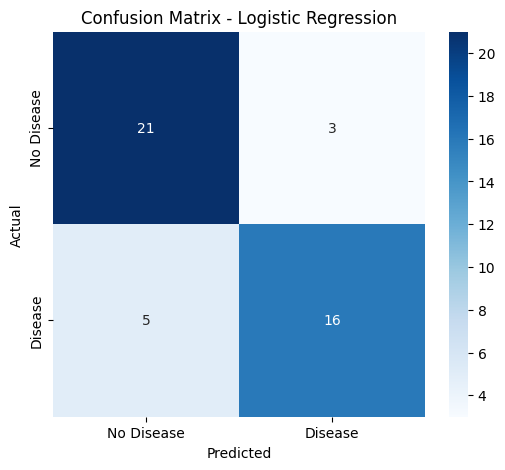

In [229]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [230]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

print("Decision Tree model created successfully!")

Decision Tree model created successfully!


In [231]:
tree_model.fit(X_train_final, y_train)

print("Decision Tree training completed successfully!")

Decision Tree training completed successfully!


In [232]:
tree_val_pred = tree_model.predict(X_val_final)

print("Decision Tree Validation Predictions:")
print(tree_val_pred)

Decision Tree Validation Predictions:
[0 1 1 0 1 0 1 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 1
 0 0 0 1 1 1 1 1]


In [233]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tree_accuracy = accuracy_score(y_val, tree_val_pred)
tree_precision = precision_score(y_val, tree_val_pred)
tree_recall = recall_score(y_val, tree_val_pred)
tree_f1 = f1_score(y_val, tree_val_pred)

print("Decision Tree Validation Accuracy:", tree_accuracy)
print("Decision Tree Validation Precision:", tree_precision)
print("Decision Tree Validation Recall:", tree_recall)
print("Decision Tree Validation F1-Score:", tree_f1)

Decision Tree Validation Accuracy: 0.6222222222222222
Decision Tree Validation Precision: 0.5909090909090909
Decision Tree Validation Recall: 0.6190476190476191
Decision Tree Validation F1-Score: 0.6046511627906976


In [234]:
from sklearn.metrics import confusion_matrix

tree_cm = confusion_matrix(y_val, tree_val_pred)

print("Decision Tree Confusion Matrix:")
print(tree_cm)

Decision Tree Confusion Matrix:
[[15  9]
 [ 8 13]]


In [235]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [236]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [237]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_val, rf_val_pred)
rf_precision = precision_score(y_val, rf_val_pred)
rf_recall = recall_score(y_val, rf_val_pred)
rf_f1 = f1_score(y_val, rf_val_pred)

print("Random Forest Validation Accuracy:", rf_accuracy)
print("Random Forest Validation Precision:", rf_precision)
print("Random Forest Validation Recall:", rf_recall)
print("Random Forest Validation F1-Score:", rf_f1)

Random Forest Validation Accuracy: 0.7777777777777778
Random Forest Validation Precision: 0.7391304347826086
Random Forest Validation Recall: 0.8095238095238095
Random Forest Validation F1-Score: 0.7727272727272727


In [238]:
from sklearn.svm import SVC

svm_model = SVC(
    random_state=42
)

print("SVM model created successfully!")

SVM model created successfully!


In [239]:
svm_model.fit(X_train_final, y_train)

print("SVM training completed successfully!")

SVM training completed successfully!


In [240]:
svm_val_pred = svm_model.predict(X_val_final)

print("SVM Validation Predictions:")
print(svm_val_pred)

SVM Validation Predictions:
[0 0 1 0 0 1 1 1 0 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0 0
 0 0 1 0 1 1 1 0]


In [241]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

svm_accuracy = accuracy_score(y_val, svm_val_pred)
svm_precision = precision_score(y_val, svm_val_pred)
svm_recall = recall_score(y_val, svm_val_pred)
svm_f1 = f1_score(y_val, svm_val_pred)

print("SVM Validation Accuracy:", svm_accuracy)
print("SVM Validation Precision:", svm_precision)
print("SVM Validation Recall:", svm_recall)
print("SVM Validation F1-Score:", svm_f1)

SVM Validation Accuracy: 0.8222222222222222
SVM Validation Precision: 0.8421052631578947
SVM Validation Recall: 0.7619047619047619
SVM Validation F1-Score: 0.8


In [242]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

print("KNN model created successfully!")

KNN model created successfully!


In [243]:
# Train the KNN model
knn_model.fit(X_train_final, y_train)

print("KNN training completed successfully!")

KNN training completed successfully!


In [244]:
# Make predictions on validation data
y_val_pred_knn = knn_model.predict(X_val_final)

print("Validation predictions:")
print(y_val_pred_knn)



Validation predictions:
[0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 1 0]


In [245]:
# Evaluate the KNN model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy_knn = accuracy_score(y_val, y_val_pred_knn)
precision_knn = precision_score(y_val, y_val_pred_knn)
recall_knn = recall_score(y_val, y_val_pred_knn)
f1_knn = f1_score(y_val, y_val_pred_knn)

print("\nKNN Validation Results:")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1 Score :", f1_knn)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_knn))


KNN Validation Results:
Accuracy : 0.8222222222222222
Precision: 0.8823529411764706
Recall   : 0.7142857142857143
F1 Score : 0.7894736842105263

Confusion Matrix:
[[22  2]
 [ 6 15]]


In [246]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Cross-validation setup
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# --------------------------------------------------
# 1. Logistic Regression Hyperparameter Tuning
# --------------------------------------------------

lr_model = LogisticRegression(
    random_state=42,
    max_iter=2000
)

lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_params,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid.fit(X_train_final, y_train)

print("Best Logistic Regression parameters:")
print(lr_grid.best_params_)

print("\nBest Logistic Regression CV Accuracy:")
print(lr_grid.best_score_)


# --------------------------------------------------
# 2. SVM Hyperparameter Tuning
# --------------------------------------------------

svm_model_tuned = SVC(
    random_state=42
)

svm_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    estimator=svm_model_tuned,
    param_grid=svm_params,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train_final, y_train)

print("\nBest SVM parameters:")
print(svm_grid.best_params_)

print("\nBest SVM CV Accuracy:")
print(svm_grid.best_score_)

Best Logistic Regression parameters:
{'C': 100, 'solver': 'liblinear'}

Best Logistic Regression CV Accuracy:
0.8348837209302324

Best SVM parameters:
{'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}

Best SVM CV Accuracy:
0.830343300110742


In [247]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ==========================================
# Tuned Logistic Regression - Validation
# ==========================================

best_lr = lr_grid.best_estimator_

y_val_pred_lr_tuned = best_lr.predict(X_val_final)

print("Tuned Logistic Regression - Validation Results")
print("Accuracy :", accuracy_score(y_val, y_val_pred_lr_tuned))
print("Precision:", precision_score(y_val, y_val_pred_lr_tuned))
print("Recall   :", recall_score(y_val, y_val_pred_lr_tuned))
print("F1 Score :", f1_score(y_val, y_val_pred_lr_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_lr_tuned))


# ==========================================
# Tuned SVM - Validation
# ==========================================

best_svm = svm_grid.best_estimator_

y_val_pred_svm_tuned = best_svm.predict(X_val_final)

print("\n\nTuned SVM - Validation Results")
print("Accuracy :", accuracy_score(y_val, y_val_pred_svm_tuned))
print("Precision:", precision_score(y_val, y_val_pred_svm_tuned))
print("Recall   :", recall_score(y_val, y_val_pred_svm_tuned))
print("F1 Score :", f1_score(y_val, y_val_pred_svm_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_svm_tuned))

Tuned Logistic Regression - Validation Results
Accuracy : 0.7555555555555555
Precision: 0.7777777777777778
Recall   : 0.6666666666666666
F1 Score : 0.717948717948718

Confusion Matrix:
[[20  4]
 [ 7 14]]


Tuned SVM - Validation Results
Accuracy : 0.8444444444444444
Precision: 0.8888888888888888
Recall   : 0.7619047619047619
F1 Score : 0.8205128205128205

Confusion Matrix:
[[22  2]
 [ 5 16]]


In [248]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score

# Try different numbers of features
k_values = [5, 10, 15, 20, 25, "all"]

results = []

for k in k_values:

    selector = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_selected = selector.fit_transform(
        X_train_final,
        y_train
    )

    scores = cross_val_score(
        SVC(
            C=0.01,
            kernel="linear",
            gamma="scale",
            random_state=42
        ),
        X_train_selected,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    results.append((k, scores.mean()))

print("Feature Selection Results:")
print()

for k, score in results:
    print(f"Features: {k}, CV Accuracy: {score:.4f}")

Feature Selection Results:

Features: 5, CV Accuracy: 0.8111
Features: 10, CV Accuracy: 0.8158
Features: 15, CV Accuracy: 0.8347
Features: 20, CV Accuracy: 0.8256
Features: 25, CV Accuracy: 0.8256
Features: all, CV Accuracy: 0.8303


In [249]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC

# Select the best 15 features using training data
selector_15 = SelectKBest(
    score_func=f_classif,
    k=15
)

X_train_15 = selector_15.fit_transform(
    X_train_final,
    y_train
)

X_val_15 = selector_15.transform(
    X_val_final
)

X_test_15 = selector_15.transform(
    X_test_final
)

print("Original number of features:", X_train_final.shape[1])
print("Selected number of features:", X_train_15.shape[1])


# Create SVM with the best parameters found earlier
svm_15 = SVC(
    C=0.01,
    kernel="linear",
    gamma="scale",
    random_state=42
)

# Train
svm_15.fit(X_train_15, y_train)

# Validation prediction
y_val_pred_svm_15 = svm_15.predict(X_val_15)


# Evaluation
print("\nSVM with 15 Selected Features - Validation Results")

print("Accuracy :", accuracy_score(y_val, y_val_pred_svm_15))
print("Precision:", precision_score(y_val, y_val_pred_svm_15))
print("Recall   :", recall_score(y_val, y_val_pred_svm_15))
print("F1 Score :", f1_score(y_val, y_val_pred_svm_15))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_svm_15))

Original number of features: 28
Selected number of features: 15

SVM with 15 Selected Features - Validation Results
Accuracy : 0.8444444444444444
Precision: 0.8888888888888888
Recall   : 0.7619047619047619
F1 Score : 0.8205128205128205

Confusion Matrix:
[[22  2]
 [ 5 16]]


In [250]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

print("Gradient Boosting model created successfully!")

# Train
gb_model.fit(X_train_final, y_train)

print("Gradient Boosting training completed successfully!")

# Validation prediction
y_val_pred_gb = gb_model.predict(X_val_final)

# Evaluation
print("\nGradient Boosting - Validation Results")

print("Accuracy :", accuracy_score(y_val, y_val_pred_gb))
print("Precision:", precision_score(y_val, y_val_pred_gb))
print("Recall   :", recall_score(y_val, y_val_pred_gb))
print("F1 Score :", f1_score(y_val, y_val_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_gb))

Gradient Boosting model created successfully!
Gradient Boosting training completed successfully!

Gradient Boosting - Validation Results
Accuracy : 0.8
Precision: 0.7727272727272727
Recall   : 0.8095238095238095
F1 Score : 0.7906976744186046

Confusion Matrix:
[[19  5]
 [ 4 17]]


In [251]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# ------------------------------------------
# 1. Define feature groups
# ------------------------------------------

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]


# ------------------------------------------
# 2. Numerical preprocessing
# ------------------------------------------

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# ------------------------------------------
# 3. Categorical preprocessing
# ------------------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# ------------------------------------------
# 4. Combine preprocessing
# ------------------------------------------

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])


# ------------------------------------------
# 5. Complete SVM pipeline
# ------------------------------------------

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(random_state=42))
])


# ------------------------------------------
# 6. Parameters to test
# ------------------------------------------

svm_pipeline_params = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf", "poly"],
    "model__gamma": ["scale", "auto"]
}


# ------------------------------------------
# 7. 5-Fold Cross Validation
# ------------------------------------------

cv_pipeline = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------
# 8. Grid Search
# ------------------------------------------

svm_pipeline_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_pipeline_params,
    cv=cv_pipeline,
    scoring="accuracy",
    n_jobs=-1
)


# ------------------------------------------
# 9. Train
# ------------------------------------------

svm_pipeline_grid.fit(X_train, y_train)


# ------------------------------------------
# 10. Results
# ------------------------------------------

print("Best SVM Pipeline Parameters:")
print(svm_pipeline_grid.best_params_)

print("\nBest SVM Pipeline CV Accuracy:")
print(svm_pipeline_grid.best_score_)

Best SVM Pipeline Parameters:
{'model__C': 0.01, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Best SVM Pipeline CV Accuracy:
0.830343300110742


In [252]:
# Get the best leakage-safe SVM pipeline
best_svm_pipeline = svm_pipeline_grid.best_estimator_

# Predict on validation data
y_val_pred_pipeline = best_svm_pipeline.predict(X_val)

# Evaluate
print("Leakage-Safe SVM Pipeline - Validation Results")

print("Accuracy :", accuracy_score(y_val, y_val_pred_pipeline))
print("Precision:", precision_score(y_val, y_val_pred_pipeline))
print("Recall   :", recall_score(y_val, y_val_pred_pipeline))
print("F1 Score :", f1_score(y_val, y_val_pred_pipeline))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_pipeline))

Leakage-Safe SVM Pipeline - Validation Results
Accuracy : 0.8444444444444444
Precision: 0.8888888888888888
Recall   : 0.7619047619047619
F1 Score : 0.8205128205128205

Confusion Matrix:
[[22  2]
 [ 5 16]]


In [253]:
# ==========================================
# FINAL SVM TEST EVALUATION
# ==========================================

# Use the best leakage-safe SVM pipeline
final_svm_model = svm_pipeline_grid.best_estimator_

# Make predictions on the untouched test set
y_test_pred_svm = final_svm_model.predict(X_test)

# Evaluate final SVM
print("========== FINAL SVM TEST RESULTS ==========")

print("Accuracy :", accuracy_score(y_test, y_test_pred_svm))
print("Precision:", precision_score(y_test, y_test_pred_svm))
print("Recall   :", recall_score(y_test, y_test_pred_svm))
print("F1 Score :", f1_score(y_test, y_test_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_svm))

========== FINAL SVM TEST RESULTS ==========
Accuracy : 0.9130434782608695
Precision: 0.9047619047619048
Recall   : 0.9047619047619048
F1 Score : 0.9047619047619048

Confusion Matrix:
[[23  2]
 [ 2 19]]


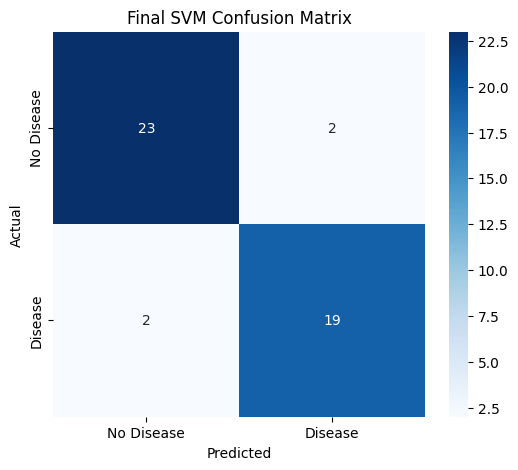

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create final confusion matrix
cm_final = confusion_matrix(y_test, y_test_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final SVM Confusion Matrix")

plt.show()

In [255]:
from sklearn.metrics import classification_report

print("Final SVM Classification Report")
print(
    classification_report(
        y_test,
        y_test_pred_svm,
        target_names=["No Disease", "Disease"]
    )
)

Final SVM Classification Report
              precision    recall  f1-score   support

  No Disease       0.92      0.92      0.92        25
     Disease       0.90      0.90      0.90        21

    accuracy                           0.91        46
   macro avg       0.91      0.91      0.91        46
weighted avg       0.91      0.91      0.91        46



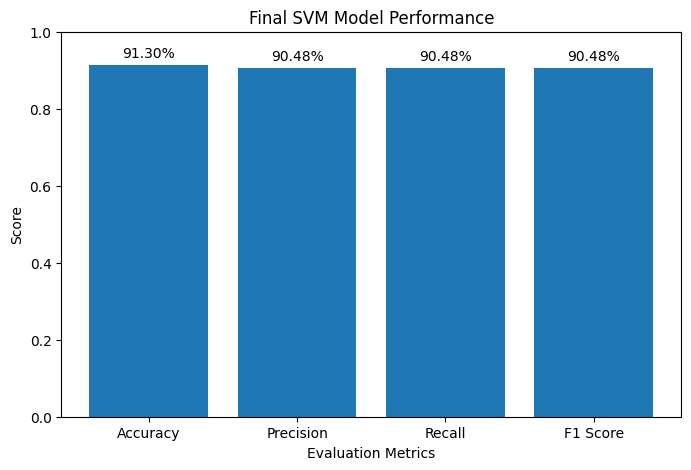

In [256]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [
    accuracy_score(y_test, y_test_pred_svm),
    precision_score(y_test, y_test_pred_svm),
    recall_score(y_test, y_test_pred_svm),
    f1_score(y_test, y_test_pred_svm)
]

plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Final SVM Model Performance")

# Display values on top of bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.show()

In [257]:
import joblib
import json

# ==========================================
# 1. Save the final SVM pipeline
# ==========================================

joblib.dump(
    final_svm_model,
    "final_svm_model.pkl"
)

print("Final SVM model saved successfully!")


# ==========================================
# 2. Save model information
# ==========================================

model_info = {
    "model": "Support Vector Machine (SVM)",
    "kernel": "linear",
    "C": 0.01,
    "gamma": "scale",
    "test_accuracy": 0.9130434782608695,
    "test_precision": 0.9047619047619048,
    "test_recall": 0.9047619047619048,
    "test_f1_score": 0.9047619047619048
}

with open("final_svm_model_info.json", "w") as file:
    json.dump(model_info, file, indent=4)

print("Model information saved successfully!")


# ==========================================
# 3. Check saved files
# ==========================================

import os

print("\nSaved files:")

for file_name in [
    "final_svm_model.pkl",
    "final_svm_model_info.json"
]:
    if os.path.exists(file_name):
        size = os.path.getsize(file_name) / 1024
        print(f"✓ {file_name} ({size:.2f} KB)")
    else:
        print(f"✗ {file_name} not found")

Final SVM model saved successfully!
Model information saved successfully!

Saved files:
✓ final_svm_model.pkl (41.07 KB)
✓ final_svm_model_info.json (0.26 KB)


In [258]:
import joblib
from sklearn.metrics import accuracy_score

# Load the saved model
loaded_svm_model = joblib.load("final_svm_model.pkl")

print("Saved SVM model loaded successfully!")

# Make predictions using the loaded model
loaded_test_predictions = loaded_svm_model.predict(X_test)

# Verify predictions
loaded_accuracy = accuracy_score(
    y_test,
    loaded_test_predictions
)

print("Loaded Model Test Accuracy:", loaded_accuracy)

# Check whether predictions are identical
same_predictions = (loaded_test_predictions == y_test_pred_svm).all()

print("Predictions identical to original model:", same_predictions)

Saved SVM model loaded successfully!
Loaded Model Test Accuracy: 0.9130434782608695
Predictions identical to original model: True


In [259]:
# ==========================================
# STEP 6.1 — NEW PATIENT PREDICTION FUNCTION
# ==========================================

import joblib
import pandas as pd

# Load the saved final SVM model
loaded_svm_model = joblib.load("final_svm_model.pkl")

def predict_heart_disease(
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
):

    # Create a DataFrame using the original feature names
    patient = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal
    }])

    # Make prediction
    prediction = loaded_svm_model.predict(patient)[0]

    # Display result
    print("========== HEART DISEASE PREDICTION ==========")

    if prediction == 1:
        print("Prediction: Disease")
    else:
        print("Prediction: No Disease")

    return prediction

In [260]:
# Example patient
prediction = predict_heart_disease(
    age=55,
    sex=1,
    cp=2,
    trestbps=130,
    chol=250,
    fbs=0,
    restecg=1,
    thalach=150,
    exang=0,
    oldpeak=1.0,
    slope=2,
    ca=0,
    thal=3
)

print("\nReturned prediction:", prediction)

========== HEART DISEASE PREDICTION ==========
Prediction: No Disease

Returned prediction: 0


In [261]:
# ==========================================
# STEP 6.3 — PREDICTION + DECISION SCORE
# ==========================================

def predict_heart_disease_with_score(
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
):

    patient = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal
    }])

    # Make prediction
    prediction = loaded_svm_model.predict(patient)[0]

    # Get SVM decision score
    decision_score = loaded_svm_model.decision_function(patient)[0]

    print("========== HEART DISEASE PREDICTION ==========")

    if prediction == 1:
        print("Prediction: Disease")
    else:
        print("Prediction: No Disease")

    print(f"Decision Score: {decision_score:.4f}")

    return prediction, decision_score

In [262]:
prediction, decision_score = predict_heart_disease_with_score(
    age=55,
    sex=1,
    cp=2,
    trestbps=130,
    chol=250,
    fbs=0,
    restecg=1,
    thalach=150,
    exang=0,
    oldpeak=1.0,
    slope=2,
    ca=0,
    thal=3
)

========== HEART DISEASE PREDICTION ==========
Prediction: No Disease
Decision Score: -0.5609


In [263]:
# ==========================================
# STEP 7.1 — FINAL PROJECT RESULTS SUMMARY
# ==========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate final metrics
final_accuracy = accuracy_score(y_test, y_test_pred_svm)
final_precision = precision_score(y_test, y_test_pred_svm)
final_recall = recall_score(y_test, y_test_pred_svm)
final_f1 = f1_score(y_test, y_test_pred_svm)

print("=" * 50)
print("       FINAL PROJECT RESULTS")
print("=" * 50)

print(f"Final Model      : Support Vector Machine (SVM)")
print(f"Test Samples     : {len(y_test)}")
print(f"Accuracy         : {final_accuracy:.2%}")
print(f"Precision        : {final_precision:.2%}")
print(f"Recall           : {final_recall:.2%}")
print(f"F1 Score         : {final_f1:.2%}")

print("\nFinal Model Status:")
if final_accuracy >= 0.90:
    print("✓ Accuracy target of 90% achieved")
else:
    print("✗ Accuracy target of 90% not achieved")

print("\nModel saved as:")
print("✓ final_svm_model.pkl")

print("\nProject completed successfully!")
print("=" * 50)

       FINAL PROJECT RESULTS
Final Model      : Support Vector Machine (SVM)
Test Samples     : 46
Accuracy         : 91.30%
Precision        : 90.48%
Recall           : 90.48%
F1 Score         : 90.48%

Final Model Status:
✓ Accuracy target of 90% achieved

Model saved as:
✓ final_svm_model.pkl

Project completed successfully!
